In [30]:
from maad import sound, features, util

s, fs = sound.load('./data/cold_forest_daylight.wav', detrend=False)

Sxx, tn, fn, ext = sound.spectrogram (s, fs, nperseg=512, noverlap=0, mode='amplitude', detrend=False, flims=(0,22050)) 

_, _, ACI  = maad.features.acoustic_complexity_index(Sxx) # Agregar min_freq, max_freq

BI = maad.features.bioacoustics_index(Sxx, fn, flim=(2000, 8000), R_compatible='soundecology')

ADI  = features.acoustic_diversity_index(Sxx, fn, fmin=0, fmax=10000, bin_step=1000, dB_threshold=-50, index='shannon')

AEI  = maad.features.acoustic_eveness_index(Sxx, fn, fmin=0, fmax=10000, bin_step=1000, dB_threshold=-50)


print(f'ACI : {ACI:2.6f}' ) # 1704.881
print(f'BI  : {BI:2.6f} ' ) # 7.986187 
print(f'ADI : {ADI:2.6f} ') # 2.054751
print(f'AEI : {AEI:2.6f} ' )  # 0.382772


# Sxx, tn, fn, ext = sound.spectrogram (s, fs, nperseg=int(fs/10), noverlap=0, mode='amplitude', detrend=False, flims=(0, 6000)) 
# _, _ , ACI  = maad.features.acoustic_complexity_index(Sxx) # Agregar min_freq, max_freq
# print('ACI : %2.6f  Freq {8000}' %ACI) # 1704.881


ACI : 156.406686
BI  : 6.018613 
ADI : 2.207403 
AEI : 0.241522 


SoundEcology Code

´´´r
# Load the tuneR library
library(tuneR)

wave_file <- './data/cold_forest_daylight.wav'
soundfile <- readWave(wave_file)

#Load the package
library(soundecology)

# ACI
acoustic_complexity(soundfile, min_freq = NA, max_freq = NA, j = 5, fft_w = 512)

# BI
bioindex <- bioacoustic_index(soundfile, min_freq = 2000, max_freq = 8000, fft_w = 512)
print(bioindex$left_area)

# ADI
result <- acoustic_diversity(soundfile, max_freq = 10000, db_threshold = -50,
freq_step = 1000, shannon = TRUE)
print(result$adi_left)

# AEI
result <- acoustic_evenness(soundfile, max_freq = 10000, db_threshold = -50, freq_step = 1000)
print(result$aei_left)
´´´

Tomado de: https://ljvillanueva.github.io/soundecology/intro.html

## Result:

´´´txt
 
 max_freq not set, using value of: 22050 


 min_freq not set, using value of: 0 


 This is a mono file.

 Calculating index. Please wait... 

  Acoustic Complexity Index (total): 1704.881


 This is a mono file.

 Calculating index. Please wait... 

  Bioacoustic Index: 7.986187

[1] 7.986187

 This is a mono file.

 Calculating index. Please wait... 

  Acoustic Diversity Index: 2.054751
[1] 2.054751

 This is a mono file.

 Calculating index. Please wait... 

  Acoustic Evenness Index: 0.382772
[1] 0.382772
´´´

## Spectrograms


ModuleNotFoundError: No module named 'scipy.filters'

In [15]:
from typing import Union, Any

def hz_to_mel(
    frequencies: Union[np.floating[float], np.ndarray], htk: bool = False
) -> Union[np.floating[Any], np.ndarray]:
    """Convert Hz to Mels

    Examples
    --------
    >>> librosa.hz_to_mel(60)
    0.9
    >>> librosa.hz_to_mel([110, 220, 440])
    array([ 1.65,  3.3 ,  6.6 ])

    Parameters
    ----------
    frequencies : number or np.ndarray [shape=(n,)] , float
        scalar or array of frequencies
    htk : bool
        use HTK formula instead of Slaney

    Returns
    -------
    mels : number or np.ndarray [shape=(n,)]
        input frequencies in Mels

    See Also
    --------
    mel_to_hz
    """
    frequencies = np.asanyarray(frequencies)

    if htk:
        mels: np.ndarray = 2595.0 * np.log10(1.0 + frequencies / 700.0)
        return mels

    # Fill in the linear part
    f_min = 0.0
    f_sp = 200.0 / 3

    mels = (frequencies - f_min) / f_sp

    # Fill in the log-scale part

    min_log_hz = 1000.0  # beginning of log region (Hz)
    min_log_mel = (min_log_hz - f_min) / f_sp  # same (Mels)
    logstep = np.log(6.4) / 27.0  # step size for log region

    if frequencies.ndim:
        # If we have array data, vectorize
        log_t = frequencies >= min_log_hz
        mels[log_t] = min_log_mel + np.log(frequencies[log_t] / min_log_hz) / logstep
    elif frequencies >= min_log_hz:
        # If we have scalar data, heck directly
        mels = min_log_mel + np.log(frequencies / min_log_hz) / logstep

    return mels

def mel_to_hz(
    mels: Union[np.floating[float], np.ndarray], *, htk: bool = False
) -> Union[np.floating[Any], np.ndarray]:
    """Convert mel bin numbers to frequencies

    Examples
    --------
    >>> librosa.mel_to_hz(3)
    200.

    >>> librosa.mel_to_hz([1,2,3,4,5])
    array([  66.667,  133.333,  200.   ,  266.667,  333.333])

    Parameters
    ----------
    mels : np.ndarray [shape=(n,)], float
        mel bins to convert
    htk : bool
        use HTK formula instead of Slaney

    Returns
    -------
    frequencies : np.ndarray [shape=(n,)]
        input mels in Hz

    See Also
    --------
    hz_to_mel
    """
    mels = np.asanyarray(mels)

    if htk:
        return 700.0 * (10.0 ** (mels / 2595.0) - 1.0)

    # Fill in the linear scale
    f_min = 0.0
    f_sp = 200.0 / 3
    freqs = f_min + f_sp * mels

    # And now the nonlinear scale
    min_log_hz = 1000.0  # beginning of log region (Hz)
    min_log_mel = (min_log_hz - f_min) / f_sp  # same (Mels)
    logstep = np.log(6.4) / 27.0  # step size for log region

    if mels.ndim:
        # If we have vector data, vectorize
        log_t = mels >= min_log_mel
        freqs[log_t] = min_log_hz * np.exp(logstep * (mels[log_t] - min_log_mel))
    elif mels >= min_log_mel:
        # If we have scalar data, check directly
        freqs = min_log_hz * np.exp(logstep * (mels - min_log_mel))

    return freqs

In [25]:
import warnings
from typing import Optional, Union, Literal
from numpy.typing import DTypeLike
import numpy as np

def mel(
    sr: float,
    n_fft: int,
    n_mels: int = 128,
    fmin: float = 0.0,
    fmax: Optional[float] = None,
    htk: bool = False,
    norm: Optional[Union[Literal["slaney"], float]] = "slaney",
    dtype: DTypeLike = np.float32,
) -> np.ndarray:
    """Create a Mel filter-bank.

    This produces a linear transformation matrix to project
    FFT bins onto Mel-frequency bins.

    Parameters
    ----------
    sr : number > 0 [scalar]
        sampling rate of the incoming signal

    n_fft : int > 0 [scalar]
        number of FFT components

    n_mels : int > 0 [scalar]
        number of Mel bands to generate

    fmin : float >= 0 [scalar]
        lowest frequency (in Hz)

    fmax : float >= 0 [scalar]
        highest frequency (in Hz).
        If `None`, use ``fmax = sr / 2.0``

    htk : bool [scalar]
        use HTK formula instead of Slaney

    norm : {None, 'slaney', or number} [scalar]
        If 'slaney', divide the triangular mel weights by the width of the mel band
        (area normalization).

        If numeric, use `librosa.util.normalize` to normalize each filter by to unit l_p norm.
        See `librosa.util.normalize` for a full description of supported norm values
        (including `+-np.inf`).

        Otherwise, leave all the triangles aiming for a peak value of 1.0

    dtype : np.dtype
        The data type of the output basis.
        By default, uses 32-bit (single-precision) floating point.

    Returns
    -------
    M : np.ndarray [shape=(n_mels, 1 + n_fft/2)]
        Mel transform matrix

    See Also
    --------
    librosa.util.normalize

    Notes
    -----
    This function caches at level 10.

    Examples
    --------
    >>> melfb = librosa.filters.mel(sr=22050, n_fft=2048)
    >>> melfb
    array([[ 0.   ,  0.016, ...,  0.   ,  0.   ],
           [ 0.   ,  0.   , ...,  0.   ,  0.   ],
           ...,
           [ 0.   ,  0.   , ...,  0.   ,  0.   ],
           [ 0.   ,  0.   , ...,  0.   ,  0.   ]])

    Clip the maximum frequency to 8KHz

    >>> librosa.filters.mel(sr=22050, n_fft=2048, fmax=8000)
    array([[ 0.  ,  0.02, ...,  0.  ,  0.  ],
           [ 0.  ,  0.  , ...,  0.  ,  0.  ],
           ...,
           [ 0.  ,  0.  , ...,  0.  ,  0.  ],
           [ 0.  ,  0.  , ...,  0.  ,  0.  ]])

    >>> import matplotlib.pyplot as plt
    >>> fig, ax = plt.subplots()
    >>> img = librosa.display.specshow(melfb, x_axis='linear', ax=ax)
    >>> ax.set(ylabel='Mel filter', title='Mel filter bank')
    >>> fig.colorbar(img, ax=ax)
    """
    if fmax is None:
        fmax = float(sr) / 2

    # Initialize the weights
    n_mels = int(n_mels)
    weights = np.zeros((n_mels, int(1 + n_fft // 2)), dtype=dtype)

    # Center freqs of each FFT bin
    fftfreqs = np.fft.rfftfreq(sr=sr, n_fft=n_fft)

    # 'Center freqs' of mel bands - uniformly spaced between limits
    min_mel = hz_to_mel(fmin, htk=htk)
    max_mel = hz_to_mel(fmax, htk=htk)

    mels = np.linspace(min_mel, max_mel, n_mels+2)

    mel_f = mel_to_hz(mels, htk=htk)
    # mel_f = mel_frequencies(n_mels + 2, fmin=fmin, fmax=fmax, htk=htk)

    fdiff = np.diff(mel_f)
    ramps = np.subtract.outer(mel_f, fftfreqs)

    for i in range(n_mels):
        # lower and upper slopes for all bins
        lower = -ramps[i] / fdiff[i]
        upper = ramps[i + 2] / fdiff[i + 1]

        # .. then intersect them with each other and zero
        weights[i] = np.maximum(0, np.minimum(lower, upper))

    if isinstance(norm, str):
        if norm == "slaney":
            # Slaney-style mel is scaled to be approx constant energy per channel
            enorm = 2.0 / (mel_f[2 : n_mels + 2] - mel_f[:n_mels])
            weights *= enorm[:, np.newaxis]
        else:
            raise ParameterError(f"Unsupported norm={norm}")
    else:
        weights = util.normalize(weights, norm=norm, axis=-1)

    # Only check weights if f_mel[0] is positive
    if not np.all((mel_f[:-2] == 0) | (weights.max(axis=1) > 0)):
        # This means we have an empty channel somewhere
        warnings.warn(
            "Empty filters detected in mel frequency basis. "
            "Some channels will produce empty responses. "
            "Try increasing your sampling rate (and fmax) or "
            "reducing n_mels.",
            stacklevel=2,
        )

    return weights

In [ ]:
import numpy as np 
import scipy as sp
from maad.util import power2dB, amplitude2dB, crop_image, plot2d
# from scipy.filters import mel
import matplotlib.pyplot as plt


def mel_spectrogram(x, fs, window='hann', nperseg=1024, noverlap=None,
                flims=None, tlims=None,
                # mode='psd',
                nmels = 20, htk=False, norm='slaney',
                verbose=False, display=False,
                savefig=None, **kwargs):
    """
    Description

    Parameters
    ----------
    x : 1d ndarray
        Vector containing the sound waveform 
    fs : int
        The sampling frequency in Hz 
    window : str or tuple or array_like, optional, default to 'hann'
        Desired window to use. If window is a string or tuple, it is passed to 
        get_window to generate the window values, which are DFT-even by default. 
        See get_window for a list of windows and required parameters. 
        If window is array_like it will be used directly as the window and its length must be nperseg. 
    nperseg : int, optional. Defaults to 1024.
        Length of the segment used to compute the FFT. No zero padding. 
        For fast calculation, it's better to use a number that is a power 2. 
        This parameter sets the resolution in frequency as the spectrogram will
        contains nperseg/2 frequency bins between 0Hz-(fs/2)Hz, with a resolution
        df = fs/nperseg
        It sets also the time slot (dt) of each frequency frames : dt = nperseg/fs
        The higher is the number, the lower is the resolution in time (dt) 
        but better is the resolution in frequency (df).  
    noverlap : int, optional. Defaults to None.
        Number of points to overlap between segments. 
        If None, noverlap = nperseg // 2. 
    flims, tlims : list of 2 scalars [min, max], optional, default is None
        flims corresponds to the min and max boundary frequency values
        tlims corresponds to the min and max boundary time values  
    
    nmels : int > 0, optional, default is 20
        Number of Mel bands to generate.
        The Mel scale is a perceptual scale of pitches that approximates the
        human ear's response to different frequencies.
    htk : boolean, optional, default is False
        Use HTK formula instead of Slaney
    norm : {'slaney', float} or None, optional, default is 'slaney'
        If 'slaney', the filter is scaled so that the sum of all filter
        coefficients is 1. If a float, the filter is scaled so that the maximum
        filter coefficient is equal to that float. If None, no scaling is applied.
        See https://librosa.org/doc/main/mel.html for more details.

    verbose : boolean, optional, default is False
        print messages into the consol or terminal if verbose is True   
    display : boolean, optional, default is False
        Display the signal if True
    savefig : string, optional, default is None
        Root filename (with full path) is required to save the figures. Postfix
        is added to the root filename.        
    **kwargs, optional. This parameter is used by plt.plot and savefig functions
        - savefilename : str, optional, default :'_filt_audiogram.png'
            Postfix of the figure filename
        - db_range : scalar, optional, default : 100
            if db_range is a number, anything lower than -db_range is set to 
            -db_range and anything larger than 0 is set to 0
        - figsize : tuple of integers, optional, default: (4,10)
            width, height in inches.  
        - title : string, optional, default : 'Spectrogram'
            title of the figure
        - xlabel : string, optional, default : 'Time [s]'
            label of the horizontal axis
        - ylabel : string, optional, default : 'Amplitude [AU]'
        - cmap : string or Colormap object, optional, default is 'gray'
            See https://matplotlib.org/examples/color/colormaps_reference.html
            in order to get all the  existing colormaps
            examples: 'hsv', 'hot', 'bone', 'tab20c', 'jet', 'seismic', 
            'viridis'...
        - vmin, vmax : scalar, optional, default: None
            `vmin` and `vmax` are used in conjunction with norm to normalize
            luminance data.  Note if you pass a `norm` instance, your
            settings for `vmin` and `vmax` will be ignored.

        - extent : list of scalars [left, right, bottom, top], optional, default: None
            The location, in data-coordinates, of the lower-left and
            upper-right corners. If `None`, the image is positioned such that
            the pixel centers fall on zero-based (row, column) indices.
        - dpi : integer, optional, default is 96
            Dot per inch. 
            For printed version, choose high dpi (i.e. dpi=300) => slow
            For screen version, choose low dpi (i.e. dpi=96) => fast
        - format : string, optional, default is 'png'
            Format to save the figure

        ... and more, see matplotlib  

    Returns
    -------
    Sxx : 2d ndarray of floats
        Spectrogram : Matrix containing K frames with N/2 frequency bins, 
        K*N <= length (wave)
        Sxx unit is power => Sxx_power if mode is 'psd'
        Sxx unit is amplitude => Sxx_ampli if mode is 'amplitude' or 'complex'
    tn : 1d ndarray of floats
        time vector (horizontal x-axis)    
    fn : 1d ndarray of floats
        Frequency vector (vertical y-axis)    
    extent : list of scalars [left, right, bottom, top]
        The location, in data-coordinates, of the lower-left and
        upper-right corners. 

    Notes
    -----
    This function takes care of the energy conservation which is crucial 
    when working with sound pressure level (dB SPL)

    Examples
    --------
    >>> s,fs = maad.sound.load("../data/rock_savanna.wav")

    Compute energy of signal s

    >>> E1 = sum(s**2)
    >>> maad.util.power2dB(E1)
    44.861029507805256

    Compute the spectrogram with 'psd' output (if N<4096, the energy is lost)

    >>> N = 4096
    >>> Sxx_power,tn,fn,ext = maad.sound.spectrogram (s, fs, nperseg=N, noverlap=N//2, mode = 'psd')   

    Display Power Spectrogram

    >>> Sxx_dB = maad.util.power2dB(Sxx_power) # convert into dB
    >>> fig_kwargs = {'vmax': Sxx_dB.max(),
                      'vmin':-70,
                      'extent':ext,
                      'figsize':(4,13),
                      'title':'Power spectrogram density (PSD)',
                      'xlabel':'Time [sec]',
                      'ylabel':'Frequency [Hz]',
                      }
    >>> fig, ax = maad.util.plot2d(Sxx_dB,**fig_kwargs)     

    Compute mean power spectrogram

    >>> S_power_mean = maad.sound.avg_power_spectro(Sxx_power)

    energy => power x time

    >>> E2 = sum(S_power_mean*len(s)) 
    >>> maad.util.power2dB(E2)
    44.93083283875093

    Compute the spectrogram with 'amplitude' output

    >>> Sxx_ampli,tn,fn,_ = maad.sound.spectrogram (s, fs, nperseg=N, noverlap=N//2, mode='amplitude')  

    For energy conservation => convert Sxx_ampli (amplitude) into power before doing the average.

    >>> S_ampli_mean = maad.sound.avg_amplitude_spectro(Sxx_ampli)
    >>> S_power_mean = S_ampli_mean**2

    energy => power x time

    >>> E3 = sum(S_power_mean*len(s)) 
    >>> maad.util.power2dB(E3)
    44.93083283875093

    """
    
    # Get the argument detrend. By default is "constant" but some reasons (ADI
    # and AEI index from soundecology), detrend should be None
    detrend = kwargs.pop("detrend", "constant")

    # Test if noverlap is None. By default, noverlap is half the length of the fft
    if noverlap is None:
        noverlap = nperseg // 2

    # compute the number of frames
    K = len(x)//(nperseg-noverlap)-1

    # compute spectrogram
    fn, tn, Sxx_complex = sp.signal.spectrogram(x, fs, window=window,
                                                nperseg=nperseg, noverlap=noverlap,
                                                nfft=nperseg,
                                                mode='complex',
                                                detrend=detrend,
                                                scaling='density', axis=-1)

    # Mutliply by the frequency resolution step (fs/nperseg) to get the power
    # so multiply by the sqrt((fs/nperseg)) to get the amplitude
    # Also multiply by sqrt(2) in order to compensate that only the postive frequencies are kept
    # complex
    Sxx_complex = Sxx_complex*np.sqrt(2*(fs/nperseg))
    # magnitude
    Sxx = abs(Sxx_complex)
    # power
    PSDxx = Sxx**2
    Sxx_out = PSDxx

    # test if the last frames are computed on a whole time frame.
    # if note => remove these frames
    if PSDxx.shape[1] > K:
        sup = Sxx_out.shape[1] - K
        Sxx_out = Sxx_out[:, :-sup]
        tn = tn[:-sup]

    # Remove the last frequency bin in order to obtain nperseg/2 frequency bins
    # instead of nperseg/2 + 1
    Sxx_out = Sxx_out[:, :]
    fn = fn[:-1]

    # Build a Mel filter
    mel_basis = mel(sr=fs, n_fft=nperseg, n_mels=nmels,
                    fmin=0, fmax=11025, htk=htk, norm=norm, dtype=np.float32)
    Sxx_melt_out = np.einsum("...ft,mf->...mt", Sxx_out, mel_basis, optimize=True)

    if verbose:
        print('spectrogram dimension Nx=%d Ny=%d' %
              (Sxx_complex.shape[0], Sxx_complex.shape[1]))

    # Crop the image in order to analyzed only a portion of it
    if (flims or tlims) is not None:
        if verbose:
            print('Crop the spectrogram along time axis and frequency axis')
        Sxx_melt_out, tn, fn = crop_image(Sxx_melt_out, tn, fn, flims, tlims)

    if verbose:
        print('max value of the spectrogram %.5f' % Sxx_melt_out.max())

    # Extent
    extent = [tn[0], tn[-1], fn[0], fn[-1]]
    # dt and df resolution
    dt = tn[1]-tn[0]
    df = fn[1]-fn[0]

    if verbose == True:
        print("*************************************************************")
        print("   Time resolution dt=%.2fs | Frequency resolution df=%.2fHz "
              % (dt, df))
        print("*************************************************************")

    # Display
    if display:

        ylabel = kwargs.pop('ylabel', 'Frequency [Hz]')
        xlabel = kwargs.pop('xlabel', 'Time [sec]')
        title = kwargs.pop('title', 'Spectrogram')
        cmap = kwargs.pop('cmap', 'gray')
        figsize = kwargs.pop('figsize', (4, 0.33*(extent[1]-extent[0])))
        db_range = kwargs.pop('db_range', 96)

        # convert into dB
        Sxx_disp = power2dB(Sxx_melt_out, db_range=db_range)

        vmin = kwargs.pop('vmin', -db_range)
        vmax = kwargs.pop('vmax', Sxx_disp.max())

        _, fig = plot2d(Sxx_disp, extent=extent, figsize=figsize, title=title,
                        ylabel=ylabel, xlabel=xlabel, vmin=vmin, vmax=vmax,
                        cmap=cmap, **kwargs)

        # Change y axis ticks to correspond to mel bands
        num_mels = mel_basis.shape[0]
        ax = plt.gca()
        if flims is None: 
            fmax=11025
        else:
            fmax = flims[1]

        
        
        # Set y-axis to log2 scale
        # yticks = [0]+[2**i for i in range(9, 14) if 2**i < fmax]
        # ax.set_yticks(yticks)  # Adjust 
        # ax.set_yticklabels([str(y) for y in yticks])
        # ax.set_ylim(0, fmax)
        
        # SAVE FIGURE
        if savefig is not None:
            dpi = kwargs.pop('dpi', 96)
            bbox_inches = kwargs.pop('bbox_inches', 'tight')
            format = kwargs.pop('format', 'png')
            savefilename = kwargs.pop('savefilename', '_spectrogram')
            filename = savefig+savefilename+'.'+format
            print('\n''save figure : %s' % filename)
            fig.savefig(fname=filename, dpi=dpi, bbox_inches=bbox_inches,
                        format=format, **kwargs)

    return Sxx_melt_out, tn, fn, extent

In [85]:
import librosa
from librosa.core.spectrum import _spectrogram
from librosa.filters import mel

y, sr = librosa.load(librosa.ex('trumpet'))

n_fft: int = 2048
hop_length: int = 512
win_length  = None
window = "hann"
center: bool = True
pad_mode = "constant"
power: float = 2.0


S, n_fft = _spectrogram(
    y=y,
    S=None,
    n_fft=n_fft,
    hop_length=hop_length,
    power=power,
    win_length=win_length,
    window=window,
    center=center,
    pad_mode=pad_mode,
)

# Build a Mel filter
mel_basis = mel(sr=sr, n_fft=n_fft)

melspec: np.ndarray = np.einsum("...ft,mf->...mt", S, mel_basis, optimize=True)

melspec.shape


# S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
# S.shape

(128, 230)

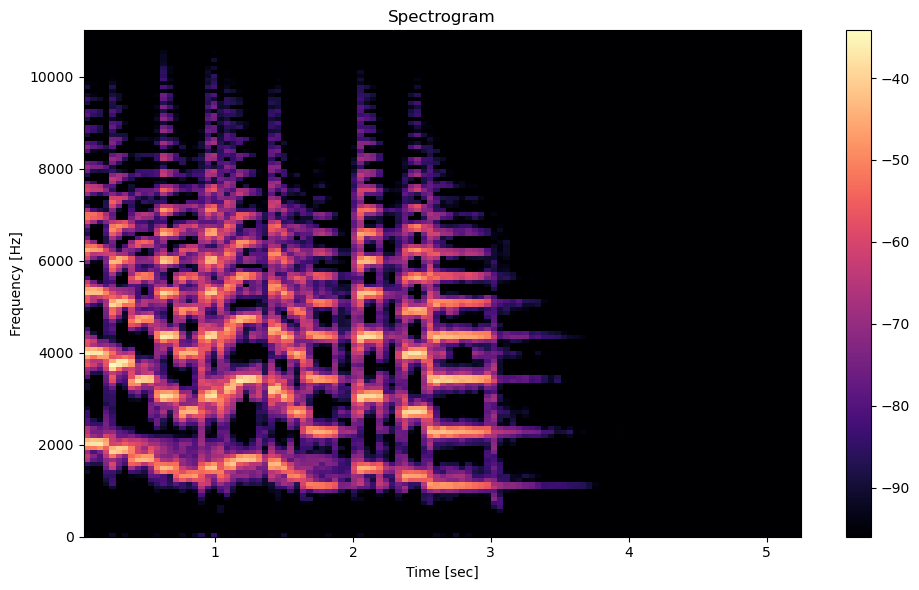

In [182]:
# y, sr = librosa.load(librosa.ex('trumpet'))

Sxx_melt_out, tn, fn, extent = mel_spectrogram(y, sr,
                window='hann', nperseg=n_fft, noverlap=None,
                flims=None, tlims=None,
                # mode='psd', htnk=False, 
                nmels = 128, norm='slaney',
                verbose=False, display=True,
                savefig=None, **{"figsize": (5,10), "cmap": "magma",})
Sxx_melt_out.shape

ax = plt.gca()

In [162]:
ax.get_yticks()
fmax=11025
[2**i for i in range(9, 14) if 2**i < fmax]
# Set y-axis to log2 scale
# ax.set_yticks([2**i for i in range(9, 13)])  # Adjust 
# ax.set_yticklabels([f"{2**i}" for i in range(9,13)])

[512, 1024, 2048, 4096, 8192]

In [183]:
sr = 22050
freq_hz = np.linspace(0, sr//2, 5)
freq_hz, hz_to_mel(freq_hz, htk=True)

(array([    0.  ,  2756.25,  5512.5 ,  8268.75, 11025.  ]),
 array([   0.        , 1799.65094691, 2460.49689868, 2874.30991445,
        3176.31843551]))

In [158]:
2595 * np.log10(1 + (freq_hz[-1]/700))
np.log2(10000)

13.287712379549449